# Perceptron

## Problem Defintions

**The perceptron answers this. It's the simplest possible learning machine: take some inputs, multiply by weights, add a bias, and make a binary decision. Then adjust. That's it.**

**Understanding the perceptron means understanding what "learning" actually means in code: adjusting numbers until the output matches reality.**

## Basic Concepts

### One Neuron, One Decision

A perceptron takes n inputs, multiplies each by a weight, sums them up, adds a bias, and passes the result through an activation function.

```mermaid
flowchart LR
A[x1] --w1--> D["z = sum(wi * xi) + b"]
B[x..] --w..--> D
C[bias] --> D
D--> E["step(z)"]
E--> F["output(0 or 1)"]
```

## Decision Boundary

For two inputs, the perceptron draws a line through 2D space.

## The Learning Rule

```
For each training example (x, y_true):
    y_pred = predict(x)
    error = y_true - y_pred

    For each weight:
        w_i = w_i + learning_rate * error * x_i
    bias = bias + learning_rate * error
```

If the prediction is correct, error = 0, nothing changes. If it predicts 0 but should be 1, weights increase. If it predicts 1 but should be 0, weights decrease. The learning rate controls how big each adjustment is.

## The XOR Problem
AND and OR are linearly separable: you can draw a single line to separate the 0s from the 1s. XOR is not. No single line can separate [0,1] and [1,0] from [0,0] and [1,1].

**The fix: stack perceptrons into layers. A multi-layer perceptron can solve XOR by combining two linear decisions into a nonlinear one.**


# Build your Own

In [ ]:
class Perceptron:
    def __init__(self, n_inputs, learning_rate=0.1):
        self.weights = [0.0] * n_inputs
        self.bias = 0.0
        self.lr = learning_rate

    def predict(self, inputs):
        total = sum(w * x for w, x in zip(self.weights, inputs))
        total += self.bias
        return 1 if total >= 0 else 0

    def train(self, training_data, epochs=100):
        for epoch in range(epochs):
            errors = 0
            for inputs, target in training_data:
                prediction = self.predict(inputs)
                error = target - prediction
                if error != 0:
                    errors += 1
                    for i in range(len(self.weights)):
                        self.weights[i] += self.lr * error * inputs[i]
                    self.bias += self.lr * error
            if errors == 0:
                print(f"Converged at epoch {epoch + 1}")
                return
        print(f"Did not converge after {epochs} epochs")

In [12]:
%matplotlib inline
def test_gate(name, n_inputs, data):
    print(f"=== {name} ===")
    p = Perceptron(n_inputs)
    p.train(data)
    print(f"  Weights: {p.weights}, Bias: {p.bias}")
    for inputs, expected in data:
        result = p.predict(inputs)
        status = "OK" if result == expected else "WRONG"
        print(f"  {inputs} -> {result} (expected {expected}) {status}")
    print()

    import matplotlib.pyplot as plt
    import numpy as np

    # Generate data points for decision boundary
    if len(data[0][0]) != 2:
        return
    x0_vals = [x[0][0] for x in data]
    x1_vals = [x[0][1] for x in data]
    x0_min, x0_max = min(x0_vals) - 0.5, max(x0_vals) + 0.5
    x0_line = np.linspace(x0_min, x0_max, 100)
    w0, w1 = p.weights
    x1_line = [-(w0 * x0 + p.bias) / w1 for x0 in x0_line]

    plt.figure(figsize=(7, 6))
    plt.scatter(x0_vals, x1_vals, c=["red" if y == 1 else "blue" for y in [x[1] for x in data]], edgecolors="k", linewidths=0.3)
    plt.plot(x0_line, x1_line, color='green', linewidth=2, label='decision boundary (p=0.5)')
    

=== AND Gate ===
Converged at epoch 4
  Weights: [0.2, 0.1], Bias: -0.20000000000000004
  [0, 0] -> 0 (expected 0) OK
  [0, 1] -> 0 (expected 0) OK
  [1, 0] -> 0 (expected 0) OK
  [1, 1] -> 1 (expected 1) OK

=== OR Gate ===
Converged at epoch 4
  Weights: [0.1, 0.1], Bias: -0.1
  [0, 0] -> 0 (expected 0) OK
  [0, 1] -> 1 (expected 1) OK
  [1, 0] -> 1 (expected 1) OK
  [1, 1] -> 1 (expected 1) OK

=== NOT Gate ===
Converged at epoch 3
  Weights: [-0.1], Bias: 0.0
  [0] -> 1 (expected 1) OK
  [1] -> 0 (expected 0) OK

=== XOR Gate (single perceptron - will fail) ===
Did not converge after 1000 epochs
  [0, 0] -> 1 (expected 0) WRONG
  [0, 1] -> 1 (expected 1) OK
  [1, 0] -> 0 (expected 1) WRONG
  [1, 1] -> 0 (expected 0) OK



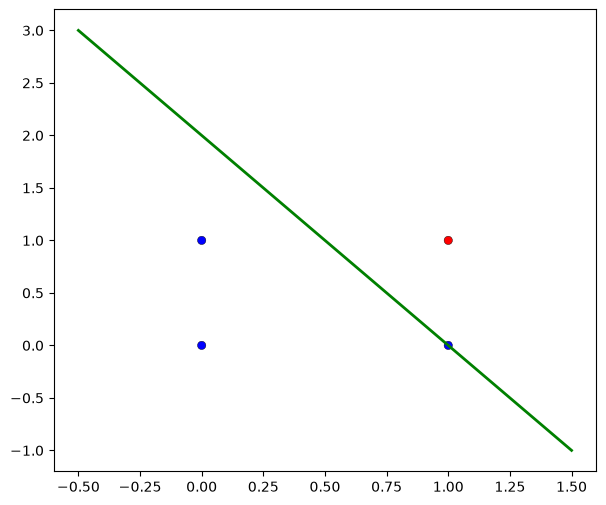

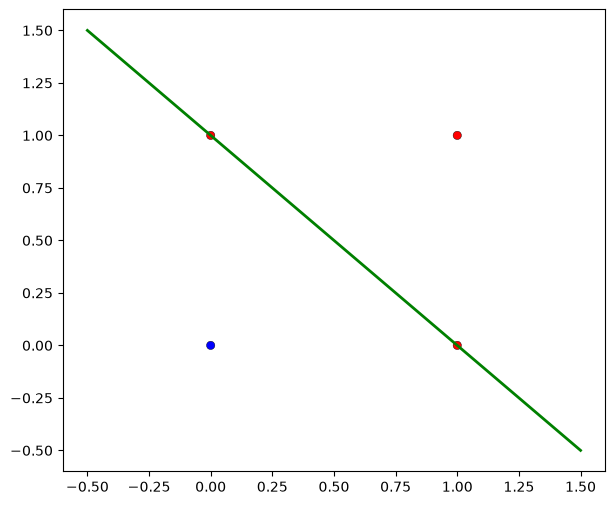

In [13]:
and_data = [
    ([0, 0], 0),
    ([0, 1], 0),
    ([1, 0], 0),
    ([1, 1], 1),
]

or_data = [
    ([0, 0], 0),
    ([0, 1], 1),
    ([1, 0], 1),
    ([1, 1], 1),
]

not_data = [
    ([0], 1),
    ([1], 0),
]

xor_data = [
    ([0, 0], 0),
    ([0, 1], 1),
    ([1, 0], 1),
    ([1, 1], 0),
]

test_gate("AND Gate", 2, and_data)
test_gate("OR Gate", 2, or_data)
test_gate("NOT Gate", 1, not_data)

print("=== XOR Gate (single perceptron - will fail) ===")
p_xor = Perceptron(2)
p_xor.train(xor_data, epochs=1000)
for inputs, expected in xor_data:
    result = p_xor.predict(inputs)
    status = "OK" if result == expected else "WRONG"
    print(f"  {inputs} -> {result} (expected {expected}) {status}")
print()

In [ ]:

def xor_network(x1, x2):
    or_neuron = Perceptron(2)
    or_neuron.weights = [1.0, 1.0]
    or_neuron.bias = -0.5

    nand_neuron = Perceptron(2)
    nand_neuron.weights = [-1.0, -1.0]
    nand_neuron.bias = 1.5

    and_neuron = Perceptron(2)
    and_neuron.weights = [1.0, 1.0]
    and_neuron.bias = -1.5

    hidden1 = or_neuron.predict([x1, x2])
    hidden2 = nand_neuron.predict([x1, x2])

    ## Similarity to
    ## (x1 or x2) and (not x1 and not x2) !!

    return and_neuron.predict([hidden1, hidden2])


print("=== XOR Gate (multi-layer network - works) ===")
for inputs, expected in xor_data:
    result = xor_network(inputs[0], inputs[1])
    status = "OK" if result == expected else "WRONG"
    print(f"  {inputs} -> {result} (expected {expected}) {status}")
print()


=== XOR Gate (multi-layer network - works) ===
  [0, 0] -> 0 (expected 0) OK
  [0, 1] -> 1 (expected 1) OK
  [1, 0] -> 1 (expected 1) OK
  [1, 1] -> 0 (expected 0) OK

